In [4]:
"""
Project Overview
----------------

This project implements Batch Gradient Descent from scratch using only NumPy.

The goal of this project is to understand the mathematical foundations
behind machine learning and neural networks without using high-level
frameworks such as TensorFlow or Scikit-learn for model training.

In this project, we manually implement:

- Weight initialization
- Bias initialization
- Matrix multiplication
- Prediction equations
- Mean Squared Error (MSE)
- Gradient calculation
- Weight updates
- Bias updates
- Cost minimization

The model learns by repeatedly adjusting weights and bias
to reduce prediction error.


These concepts are fundamental to deep learning and neural networks.
"""

'\nProject Overview\n----------------\n\nThis project implements Batch Gradient Descent from scratch using only NumPy.\n\nThe goal of this project is to understand the mathematical foundations\nbehind machine learning and neural networks without using high-level\nframeworks such as TensorFlow or Scikit-learn for model training.\n\nIn this project, we manually implement:\n\n- Weight initialization\n- Bias initialization\n- Matrix multiplication\n- Prediction equations\n- Mean Squared Error (MSE)\n- Gradient calculation\n- Weight updates\n- Bias updates\n- Cost minimization\n\nThe model learns by repeatedly adjusting weights and bias\nto reduce prediction error.\n\n\nThese concepts are fundamental to deep learning and neural networks.\n'

In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

## 1- Loading the dataset

In [6]:
url = 'https://raw.githubusercontent.com/codebasics/deep-learning-keras-tf-tutorial/refs/heads/master/8_sgd_vs_gd/homeprices_banglore.csv'

In [7]:
df = pd.read_csv(url)

In [8]:
df

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00
5,1170,2,38.00
6,2732,4,135.00
7,3300,4,155.00
8,1310,3,50.00
9,3700,5,167.00


In [9]:
x = df.drop('price', axis='columns')
y = df.price
print(f'X_shape : {x.shape} \nX_type: {type(x)} \ny_shape: {y.shape}')

X_shape : (20, 2) 
X_type: <class 'pandas.DataFrame'> 
y_shape: (20,)


## 2- Preprocessing/Scaling: Since our columns are on different sacle it is important to perform scaling on them

In [10]:
from sklearn import preprocessing

In [11]:
from sklearn import preprocessing
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

# sx and sy, these scalers need a 2D array
scaled_X = sx.fit_transform(x) # the scaller expets a 2D array
scaled_y = sy.fit_transform(y.values.reshape(df.shape[0],1))  

# <<.value>> Converts pandas series into NumPy array.
# MinMaxScaler Expects 2D Array, so we use <<reshape>> to change (df['price'].values) which is a 1D array (20,) to a 2D array (20,1)

# we latter will have to change it back to a 1D Vector, cause when we do (scaled_y -y_predicted)
# scaled_y is (20,1) and y_predicted is (20,) so we can't do (20,1) - (20,)


In [12]:
print(scaled_X)
print('-------')
print(scaled_y)

[[0.08827586 0.25      ]
 [0.62068966 0.75      ]
 [0.22068966 0.5       ]
 [0.24862069 0.5       ]
 [0.13793103 0.25      ]
 [0.12758621 0.25      ]
 [0.6662069  0.75      ]
 [0.86206897 0.75      ]
 [0.17586207 0.5       ]
 [1.         1.        ]
 [0.34482759 0.5       ]
 [0.68448276 0.75      ]
 [0.06896552 0.25      ]
 [0.10344828 0.25      ]
 [0.5        0.5       ]
 [0.12931034 0.25      ]
 [0.13103448 0.5       ]
 [0.25517241 0.5       ]
 [0.67931034 0.5       ]
 [0.         0.        ]]
-------
[[0.05237037]
 [0.65185185]
 [0.22222222]
 [0.31851852]
 [0.14074074]
 [0.04444444]
 [0.76296296]
 [0.91111111]
 [0.13333333]
 [1.        ]
 [0.37037037]
 [0.8       ]
 [0.04444444]
 [0.05925926]
 [0.51111111]
 [0.07407407]
 [0.11851852]
 [0.20740741]
 [0.51851852]
 [0.        ]]


note: now y_scaled is a 2d array (20,1) but we need to Convert it Back to 1D, gradient descent function expects a 1D array
(20,)



In [13]:
scaled_y.reshape(20,)

array([0.05237037, 0.65185185, 0.22222222, 0.31851852, 0.14074074,
       0.04444444, 0.76296296, 0.91111111, 0.13333333, 1.        ,
       0.37037037, 0.8       , 0.04444444, 0.05925926, 0.51111111,
       0.07407407, 0.11851852, 0.20740741, 0.51851852, 0.        ])

In [14]:
def batch_gradient_descent(X,y,epochs,learning_rate = 0.01):
    num_of_features = scaled_X.shape[1]
    w = np.ones(shape=num_of_features) # w.shape -> (2,)
    b = 0
    n = X.shape[0]
    cost_list = []
    epoch_list = []
    for i in range(epochs):
        
        y_predicted = np.dot(w,X.T) + b  
        # np.dot(w, X.T) performs matrix multiplication. ==> w1*x1 + w2*x2 + b
        # We use matrix multiplication to calculate predictions for ALL training examples at once.
        # X.shape -> (20,2),  X.T.shape -> (2,20)
        # We transpose X because matrix multiplication requires:  (1x2) dot (2x20), Result shape: (1x20)
        wd = -(2/n)*(X.T.dot(y-y_predicted))
        
        bd = -(2/n)*np.sum(y-y_predicted)

        w = w - learning_rate*wd
        b = b - learning_rate*bd

        cost = np.mean(np.square(y-y_predicted))  # MSE

        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
            
    return w,b,cost,cost_list,epoch_list

In [15]:
w, b, cost, cost_list, epoch_list = batch_gradient_descent(scaled_X,scaled_y.reshape(scaled_y.shape[0],),500)

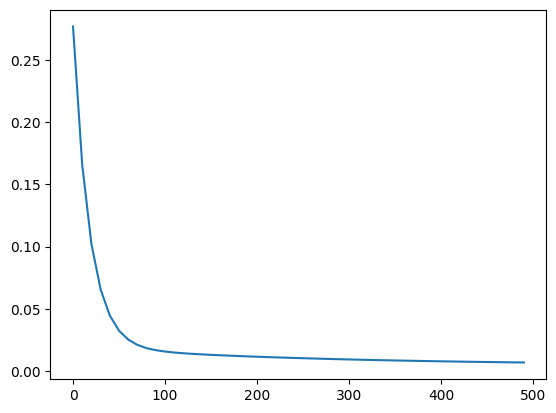

In [16]:
plt.plot(epoch_list,cost_list)

In [17]:
def predict(area, bedrooms, w, b):

    # Scale input features
    scaled_X = sx.transform([[area, bedrooms]])

    # Prediction using learned weights and bias
    scaled_prediction = (
        w[0] * scaled_X[0][0] +
        w[1] * scaled_X[0][1] +
        b
    )

    # Convert prediction back to original price scale
    y_pr = sy.inverse_transform([[scaled_prediction]])

    return y_pr



In [18]:
predict(1800,3,w,b)

/opt/anaconda3/envs/tf/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[79.35396925]])